In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import confusion_matrix
from sklearn . metrics import ConfusionMatrixDisplay

In [2]:
from sklearn.model_selection import train_test_split

data= pd.read_csv ( './data/BankData.csv'  )
data=data.drop("ID",axis=1)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB
None


## target column

since we have no instruction on which column to use as the target, i will see which columns are binary and pick one of them based on entropy to avoid picking a column that is mostly random.

In [3]:
from scipy.stats import entropy

print("Value counts:")
print("-"*20)
for col in data.columns:
    if len(data[col].value_counts())<3:
        print(data[col].value_counts())
print("-"*50)
print("Entropy:")
print("-"*20)
entropy_results = {}
for col in data.columns:
    if len(data[col].value_counts())<3:
        value_counts = data[col].value_counts(normalize=True)
        ent = entropy(value_counts, base=2) 
        entropy_results[col] = ent


sorted_entropy = sorted(entropy_results.items(), key=lambda x: x[1], reverse=True)

print("Columns sorted by entropy (highest first):")
for col, ent in sorted_entropy[:10]:
    print(f"{col}: {ent:.4f}")

Value counts:
--------------------
Personal Loan
0    4520
1     480
Name: count, dtype: int64
Securities Account
0    4478
1     522
Name: count, dtype: int64
CD Account
0    4698
1     302
Name: count, dtype: int64
Online
1    2984
0    2016
Name: count, dtype: int64
CreditCard
0    3530
1    1470
Name: count, dtype: int64
--------------------------------------------------
Entropy:
--------------------
Columns sorted by entropy (highest first):
Online: 0.9728
CreditCard: 0.8738
Securities Account: 0.4828
Personal Loan: 0.4562
CD Account: 0.3290


Online seems like a good candidate, since its the most balanced binary column. However, i still have no idea what it means, and it has the highest entropy so the models will most likely have a high error rate if i set it as the target column.

CD account has the lowest entropy, after some research into banking terms, CD account seems to mean the client has a sort of savings account. So, using it as the target column will mean trying to predict whether a client is likely to open that savings account or not. it is also the most imblanaced  of all of them. and balancing it will cause the sample size to shrink significantly affecting accuracy.

by using the previous logic i will use Personal Loan since  it meets balance and entropy in the middle.


In [4]:
from imblearn.under_sampling import RandomUnderSampler

X = data.drop(columns=['Personal Loan'])  
y = data['Personal Loan'] 

rus = RandomUnderSampler(random_state=42, sampling_strategy='auto')
X, y = rus.fit_resample(X, y)

df_balanced = pd.concat([X, y], axis=1)

print(f"New class distribution: {y.value_counts()}")

New class distribution: Personal Loan
0    480
1    480
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

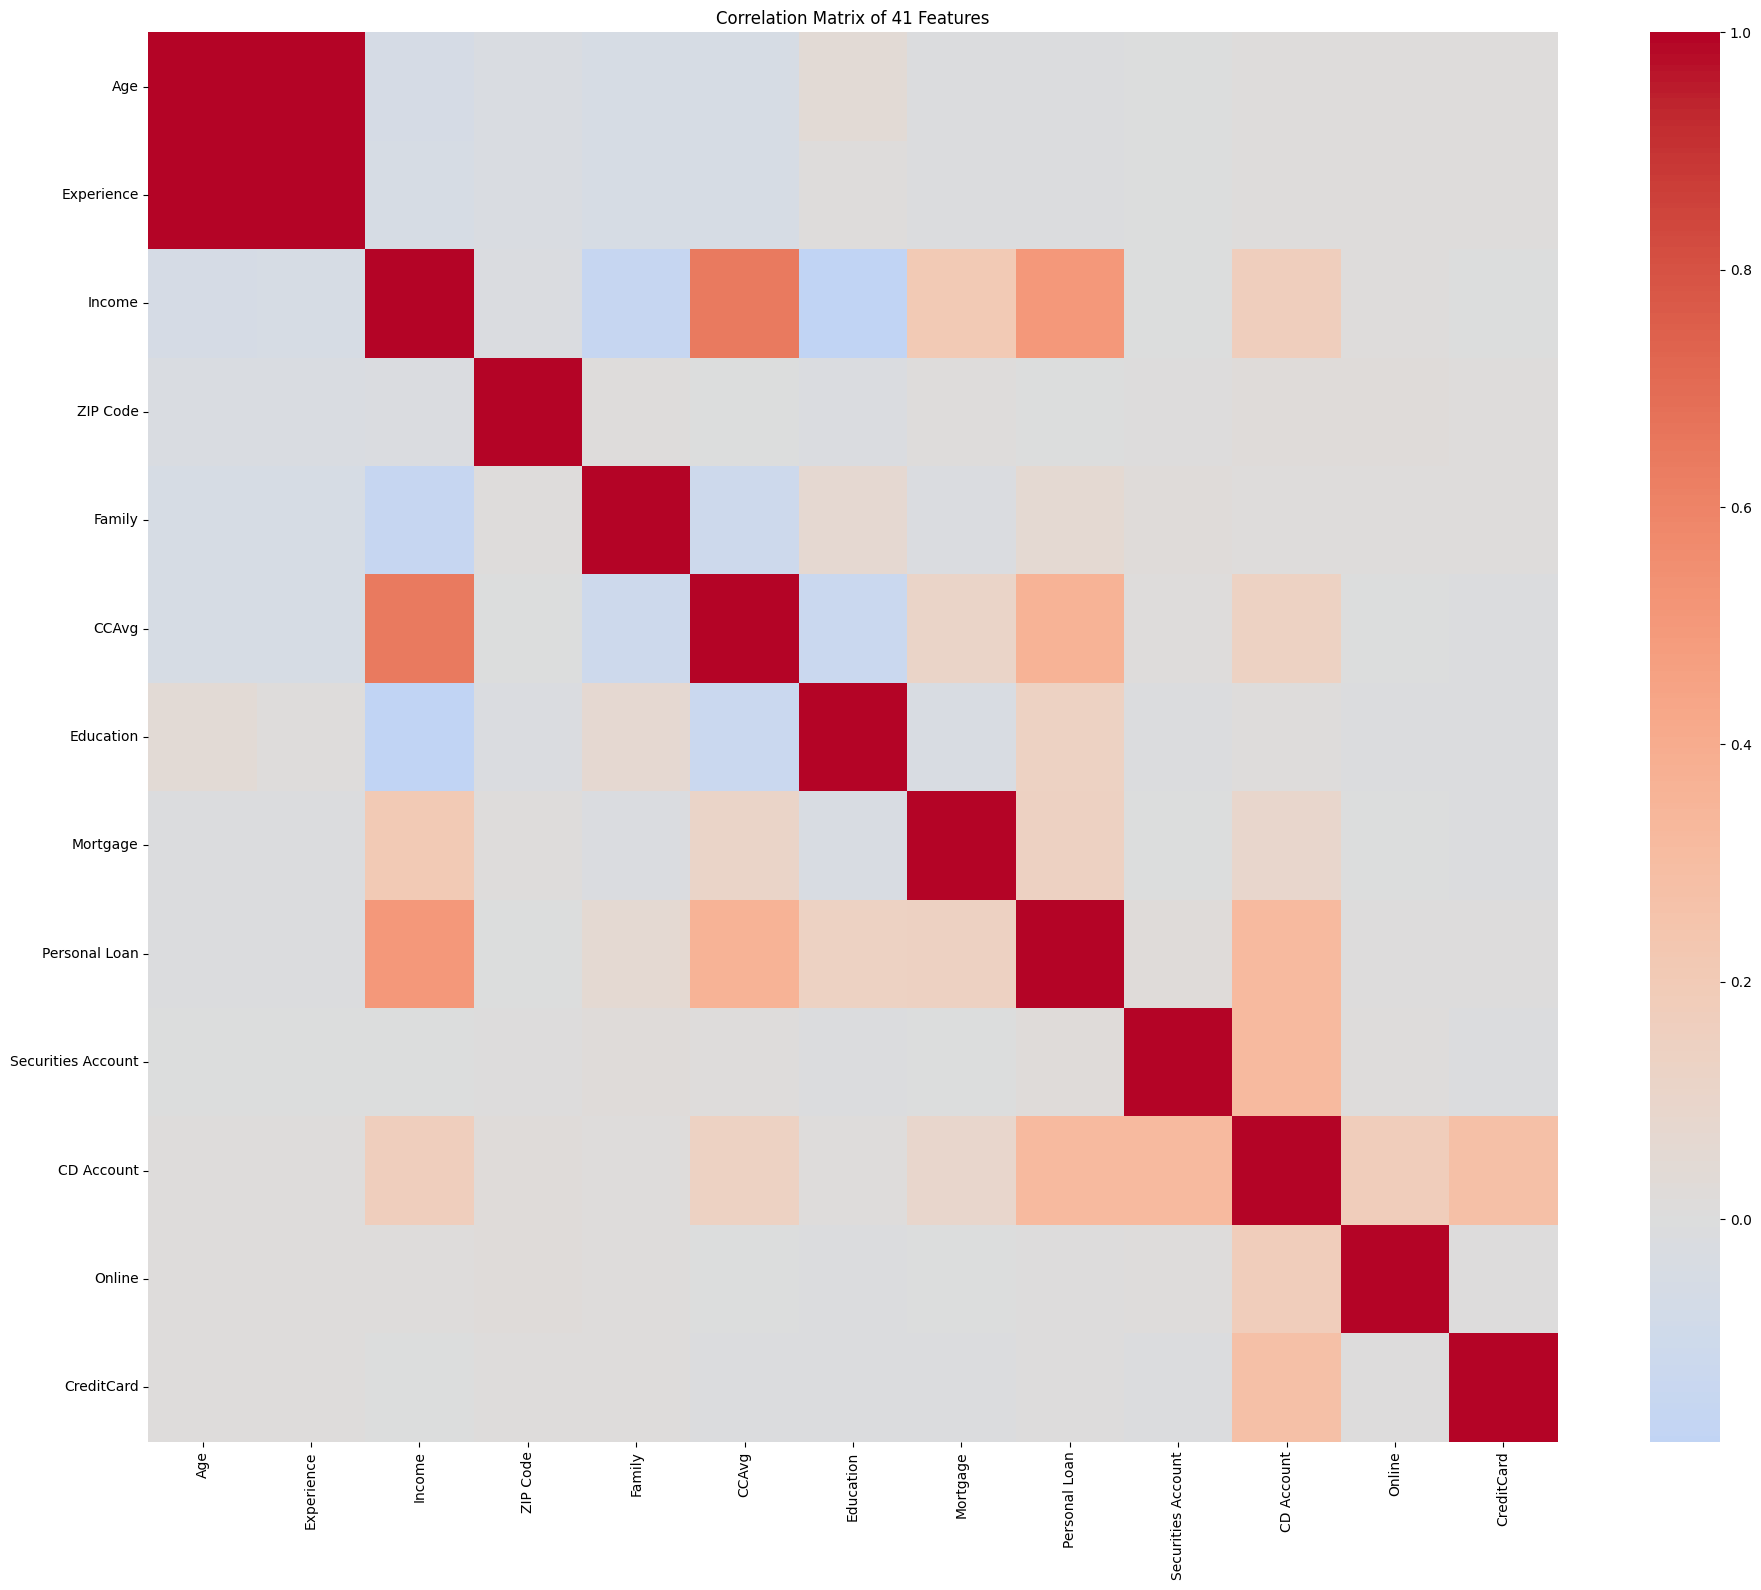

In [6]:
plt.figure(figsize=(20, 16))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of 41 Features')
plt.tight_layout()
plt.show()

age and experience are highly correlated so one of them could be removed for efficiency.

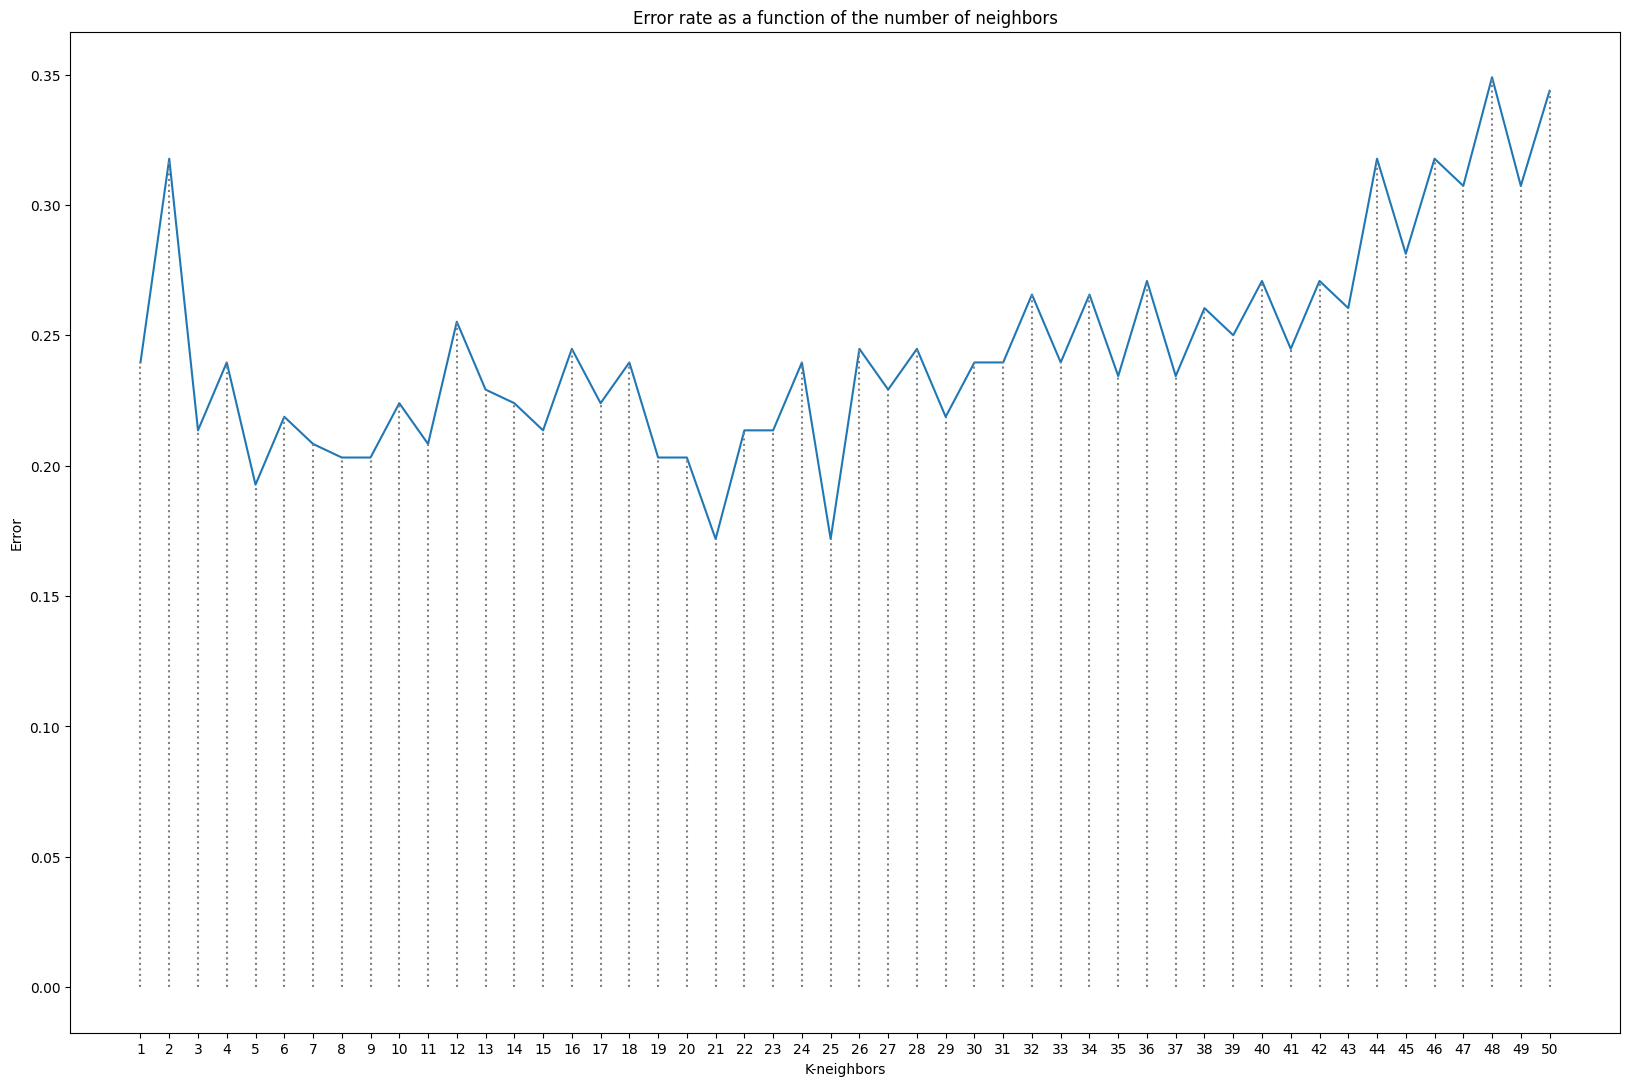

optimal k = 21
error = 0.171875


In [7]:
K=[0] * 50
optimal_k=0
optimal_error=1
for i,k in enumerate(K):
    knn = KNeighborsClassifier(n_neighbors=i+1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    K[i]=(1-accuracy)
    if K[i]<optimal_error:
        optimal_error= K[i]
        optimal_k=i+1
    
plt.figure(figsize =(20,13))
plt.plot(np.arange(1,51,1), K)
plt.xticks(np.arange(1,51,1))
plt.vlines(np.arange(1,51,1),0, K, linestyle="dotted", color="gray")
plt.xlabel("K-neighbors")
plt.ylabel("Error")
plt.title("Error rate as a function of the number of neighbors")
plt.show()

knn_error=K[optimal_k-1]

print("optimal k =",optimal_k)
print(f"error = {knn_error:.6f}" )

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred=gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
gnb_error=(1-accuracy)

print(f"error = {gnb_error:.6f}" )

error = 0.177083


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

lr . fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)

print(f"error = {lr_error:.6f}" )


error = 0.119792


/home/snds/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Comparisons:


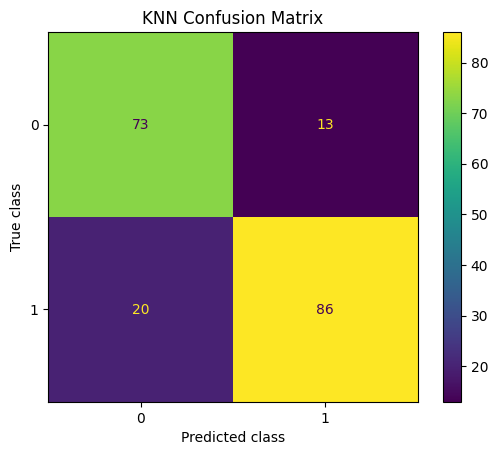

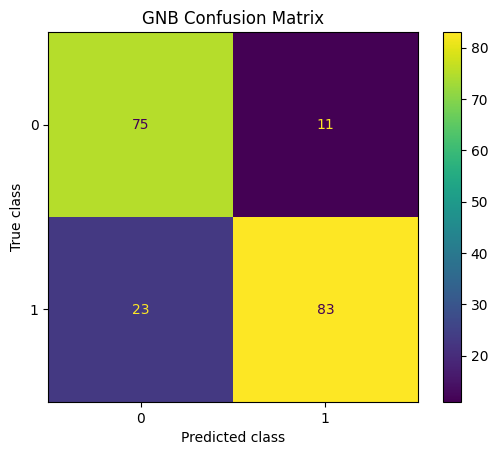

/home/snds/.local/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


error = 0.119792


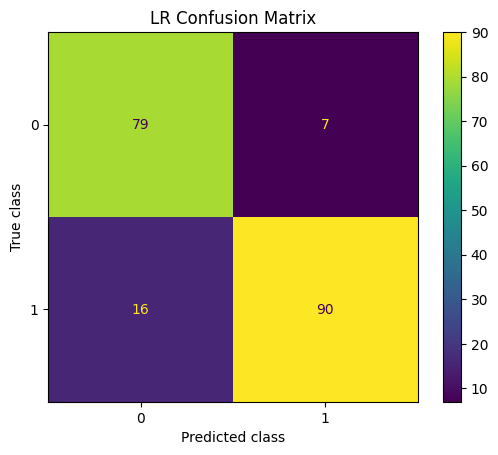

In [ ]:
###################### Knn ######################

knn = KNeighborsClassifier(n_neighbors=optimal_k)

start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()
training_duration_knn = end_time - start_time

start_time = time.time()
y_pred=knn.predict(X_test)
end_time = time.time()
prediction_time_knn = end_time - start_time
cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm)
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("KNN Confusion Matrix")
plt .show()

###################### LR ######################

gnb = GaussianNB()

start_time = time.time()
gnb.fit(X_train, y_train)
end_time = time.time()
training_duration_gnb = end_time - start_time

start_time = time.time()
y_pred=gnb.predict(X_test)
end_time = time.time()
prediction_time_gnb = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
gnb_error=(1-accuracy)

cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("GNB Confusion Matrix")
plt .show()

###################### LR ######################

lr = LogisticRegression(random_state=42, max_iter=1000)

start_time = time.time()
lr . fit(X_train, y_train)
end_time = time.time()
training_duration_lr = end_time - start_time

start_time = time.time()
y_pred = lr.predict(X_test)
end_time = time.time()
prediction_time_lr = end_time - start_time

accuracy = accuracy_score(y_test, y_pred)
lr_error=(1-accuracy)

print(f"error = {lr_error:.6f}" )

cm = confusion_matrix(y_test, y_pred)
display=ConfusionMatrixDisplay ( confusion_matrix=cm )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt.title("LR Confusion Matrix")
plt .show()


In [11]:
print("Comparisons:")
print("-"*50)
print("Test set error :")
print(f"KNN: {knn_error:.4f}")
print(f"GNB: {gnb_error:.4f}")
print(f"LR: {lr_error:.4f}")
print("-"*50)
print("Training time :")
print(f"KNN: {training_duration_knn:.4f}")
print(f"GNB: {training_duration_gnb:.4f}")
print(f"LR: {training_duration_lr:.4f}")
print("-"*50)
print("Prediction time:")
print(f"KNN: {prediction_time_knn:.4f}")
print(f"GNB: {prediction_time_gnb:.4f}")
print(f"LR: {prediction_time_lr:.4f}")
print("-"*50)

Comparisons:
--------------------------------------------------
Test set error :
KNN: 0.1719
GNB: 0.1771
LR: 0.1198
--------------------------------------------------
Training time :
KNN: 0.0075
GNB: 0.0048
LR: 0.3681
--------------------------------------------------
Prediction time:
KNN: 0.0325
GNB: 0.0024
LR: 0.0024
--------------------------------------------------


## Conslusions:
- KNN and Gaussian Naive Bayes perform similarly in accuracy (17% error), but KNN is 7–8x slower during prediction because it computes distances to all training points at inference time.

- Despite having a relatively small dataset with only 13 features, KNN's lazy learning approach (storing all data) makes prediction costly, whereas GNB builds compact models during training.

- Logistic regression perfomed slightly better (by 4%) but it took a much longer time training (60x longer to be exact).

- any analysis on these results would be negligible. We didn't know what to do with the data, so i had to make a lot of assumptions which have definitely affected the resulting statistics.